In [ ]:
# G8
# Benjamin, Hope, Mariana
# Objective: Analyze Palmer Penguin dataset using Pandas, Matplotlib, and Seaborn to uncover species differences
# Requirements:
# 3 key insights/hypotheses for submission

In [2]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load the dataset with pandas
df = pd.read_csv('penguins.csv')

# 1. Understanding the data
# Data shape. Output is formatted as (Rows, Columns). ==> (344,7)
#print(df.shape)

# Data types
#print(df.dtypes)

#print(df.head())

# Summary stats
#print(df.describe())

# Missing values

# 2. Data cleaning
# Handling the missing data values
df_clean = df.dropna(subset=['bill_length_mm', 'flipper_length_mm']).copy()
df_clean['sex'] = df_clean['sex'].fillna('Unknown')

# checking for the total of null values in each column. If 0, then no null values are in the dataframe
#print(df_clean.isnull().sum())

# checking for the number of species. This helps us know if some species were totally removed during the data cleaning
#print(df_clean['species'].value_counts()) # this is different from the values stated in the PDF (Adelie(152), Gentoo(124), Chinstrap(52))



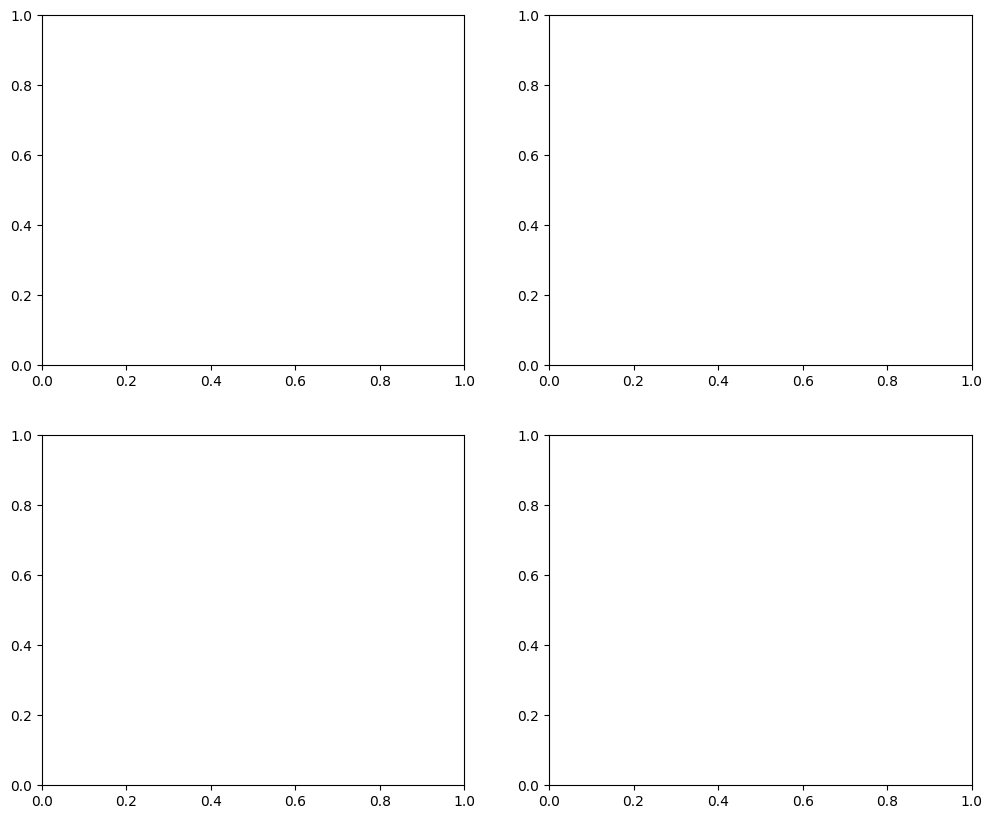

In [4]:
# diagramming

# 3. Data visualization (2 x 2 grid) with seaborn and pyplot

# Histogram
fig, ax = plt.subplots(2,2, figsize=(12,10))

# Box plot
# Scatter
# Counterplot


In [6]:
# Histogram with KDE
sns.histplot(data=df_clean, x='bill_length_mm', hue='species', kde=True, ax=ax[0,0])
ax[0,0].set_title('Bill Length by Species')

Text(0.5, 1.0, 'Bill Length by Species')

In [8]:
#Box plot
sns.boxplot(data=df_clean, x='species', y='flipper_length_mm', ax=ax[0,1])
ax[0,1].set_title('Flipper Length by Species')

Text(0.5, 1.0, 'Flipper Length by Species')

In [10]:
# scatter plot
sns.scatterplot(data=df_clean, x='bill_length_mm', y='body_mass_g', hue='species', ax=ax[1,0])
ax[1,0].set_title('Bill vs Body mass')

Text(0.5, 1.0, 'Bill vs Body mass')

In [12]:
# count plot
sns.countplot(data=df_clean, x='island', hue='species', ax=ax[1,1])
ax[1,1].set_title('Species by Island')
#if overlapping, rotate
# plt.xticks(rotation=45)

Text(0.5, 1.0, 'Species by Island')

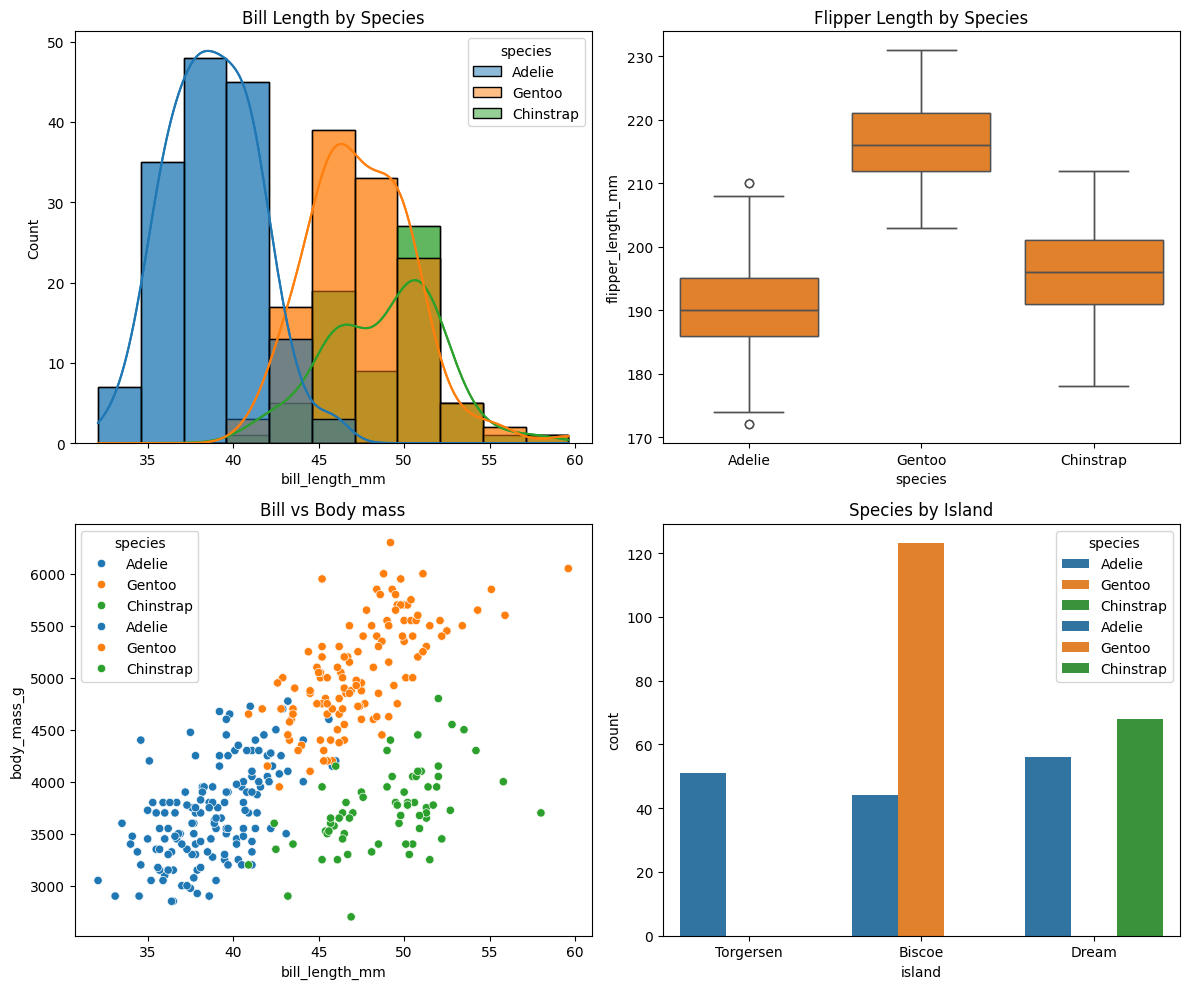

In [14]:
# show plots
fig.tight_layout()
fig

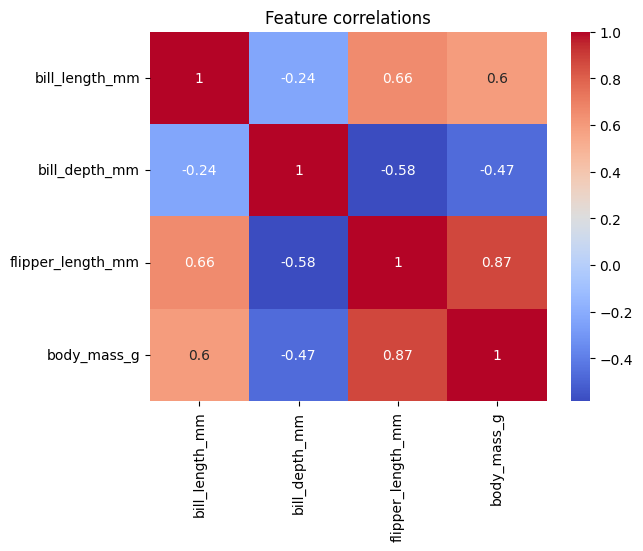

In [16]:
# Bonus: Correlation heat map and pairplot
corr = df_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Feature correlations')
plt.show()

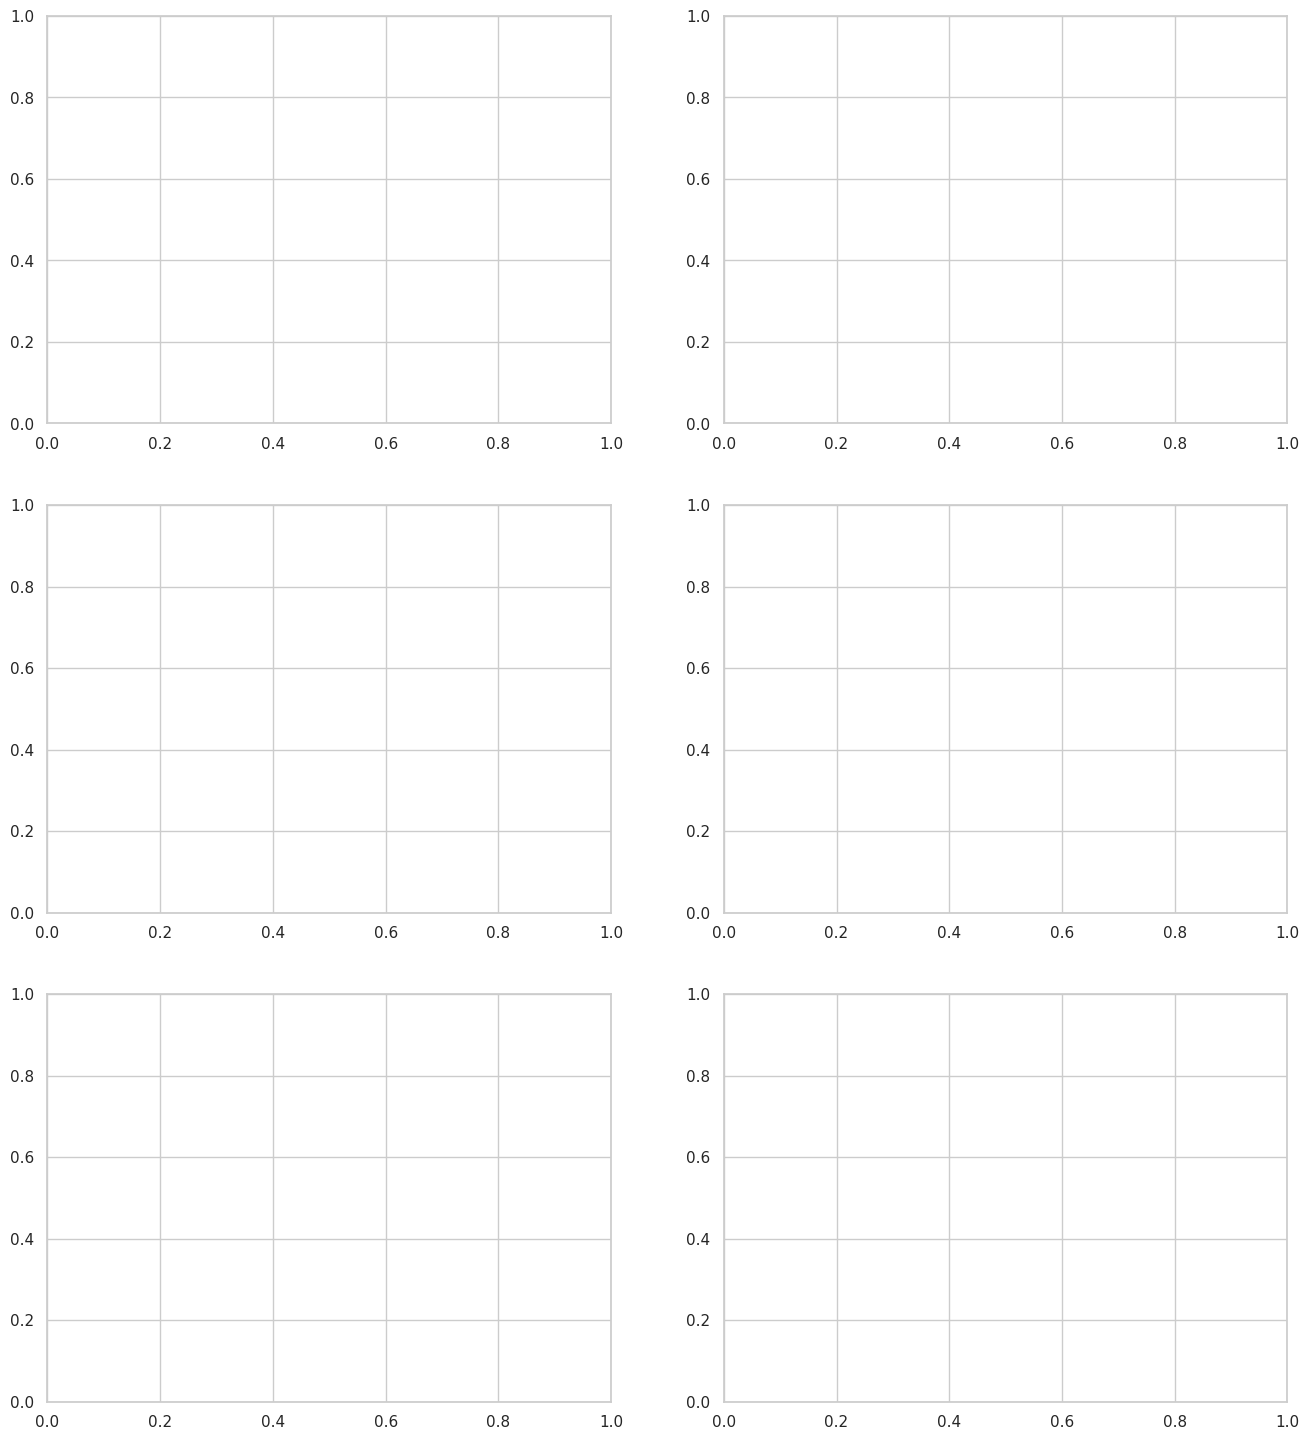

In [17]:
# Our Hypotheses

df_clean['bill_ratio'] = df_clean['bill_length_mm'] / df_clean['bill_depth_mm']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

In [18]:
# HYPOTHESIS 1
# Qn: Which penguin species has the most extreme outliers in body mass, and
# do these outliers correlate with a specific sex?

# Hypothesis: Some penguin species exhibit more outliers in body mass than others and
# this is correlated to the sex of the penguin.

# Conclusion: Given the data, Chinstrap have the most outliers (2) where males are bigger than females
# such that the outliers in males are for extreme big size and those for females are extreme small size.

sns.boxplot(data=df_clean, x='species', y='body_mass_g', hue='sex', ax=axes[0])
axes[0].set_title('H1: Body Mass Outliers by Species and Sex')

Text(0.5, 1.0, 'H1: Body Mass Outliers by Species and Sex')

In [20]:
# HYPOTHESIS 2
# Qn: On islands where multiple species coexist, is there more or less variation in body mass?

# Hypothesis: Different penguin species living on the same island show a large variation in body mass

# Conclusion: Not always. The variation is large on Biscoe island.
# There is no significant difference on Dream island

sns.violinplot(data=df_clean, x='island', y='body_mass_g', hue='species', ax=axes[1])
axes[1].set_title('H2: Mass Variation by Island Coexistence')

Text(0.5, 1.0, 'H2: Mass Variation by Island Coexistence')

In [22]:
# HYPOTHESIS 3
# Qn: Do members of the same species show significant differences in body mass depending on the island?

# Hypothesis: Adelie penguins of the same species show variation in body mass depending on the island
# (since they are the only species on all 3 islands)

# Conclusion: There is a slight variation, but it is close to insignificant.

adelie_data = df_clean[df_clean['species'] == 'Adelie']
sns.barplot(data=adelie_data, x='island', y='body_mass_g', hue='sex', ax=axes[2])
axes[2].set_title('H3: Adelie Body Mass across Different Islands')

Text(0.5, 1.0, 'H3: Adelie Body Mass across Different Islands')

In [24]:
# HYPOTHESIS 4
# Qn: How does the ratio of bill length to bill depth differ between species?

# Hypothesis: Each penguin species has a distinct ratio of bill length to bill depth

# Conclusion: Majority of bill ratios for a given species concentrate in distinct areas
# showing that there is a distinction. Due to overlap of some ratios, this is generally true but not everytime.

sns.boxplot(data=df_clean, x='species', y='bill_ratio', ax=axes[3],
            hue='species', palette='Set2', legend=False)
axes[3].set_title('H4: Distinctive Bill Ratios (Length/Depth) per Species')

Text(0.5, 1.0, 'H4: Distinctive Bill Ratios (Length/Depth) per Species')

In [26]:
# HYPOTHESIS 5
# Qn: To what extent does body mass differ between male and female penguins within each species?

# Hypothesis: Males and Female penguins of the same species show a large difference in body mass.
# (Sexual dimorphism: The existence of two distinct forms within the same species)

# Conclusion: Males are always significantly bigger than the female penguins. We can possibly tell the sex of a penguin based on body mass and species.

sns.pointplot(data=df_clean, x='species', y='body_mass_g', hue='sex', dodge=True, linestyles='none', ax=axes[4])
axes[4].set_title('H5: Extent of Sexual Dimorphism in Body Mass')

Text(0.5, 1.0, 'H5: Extent of Sexual Dimorphism in Body Mass')

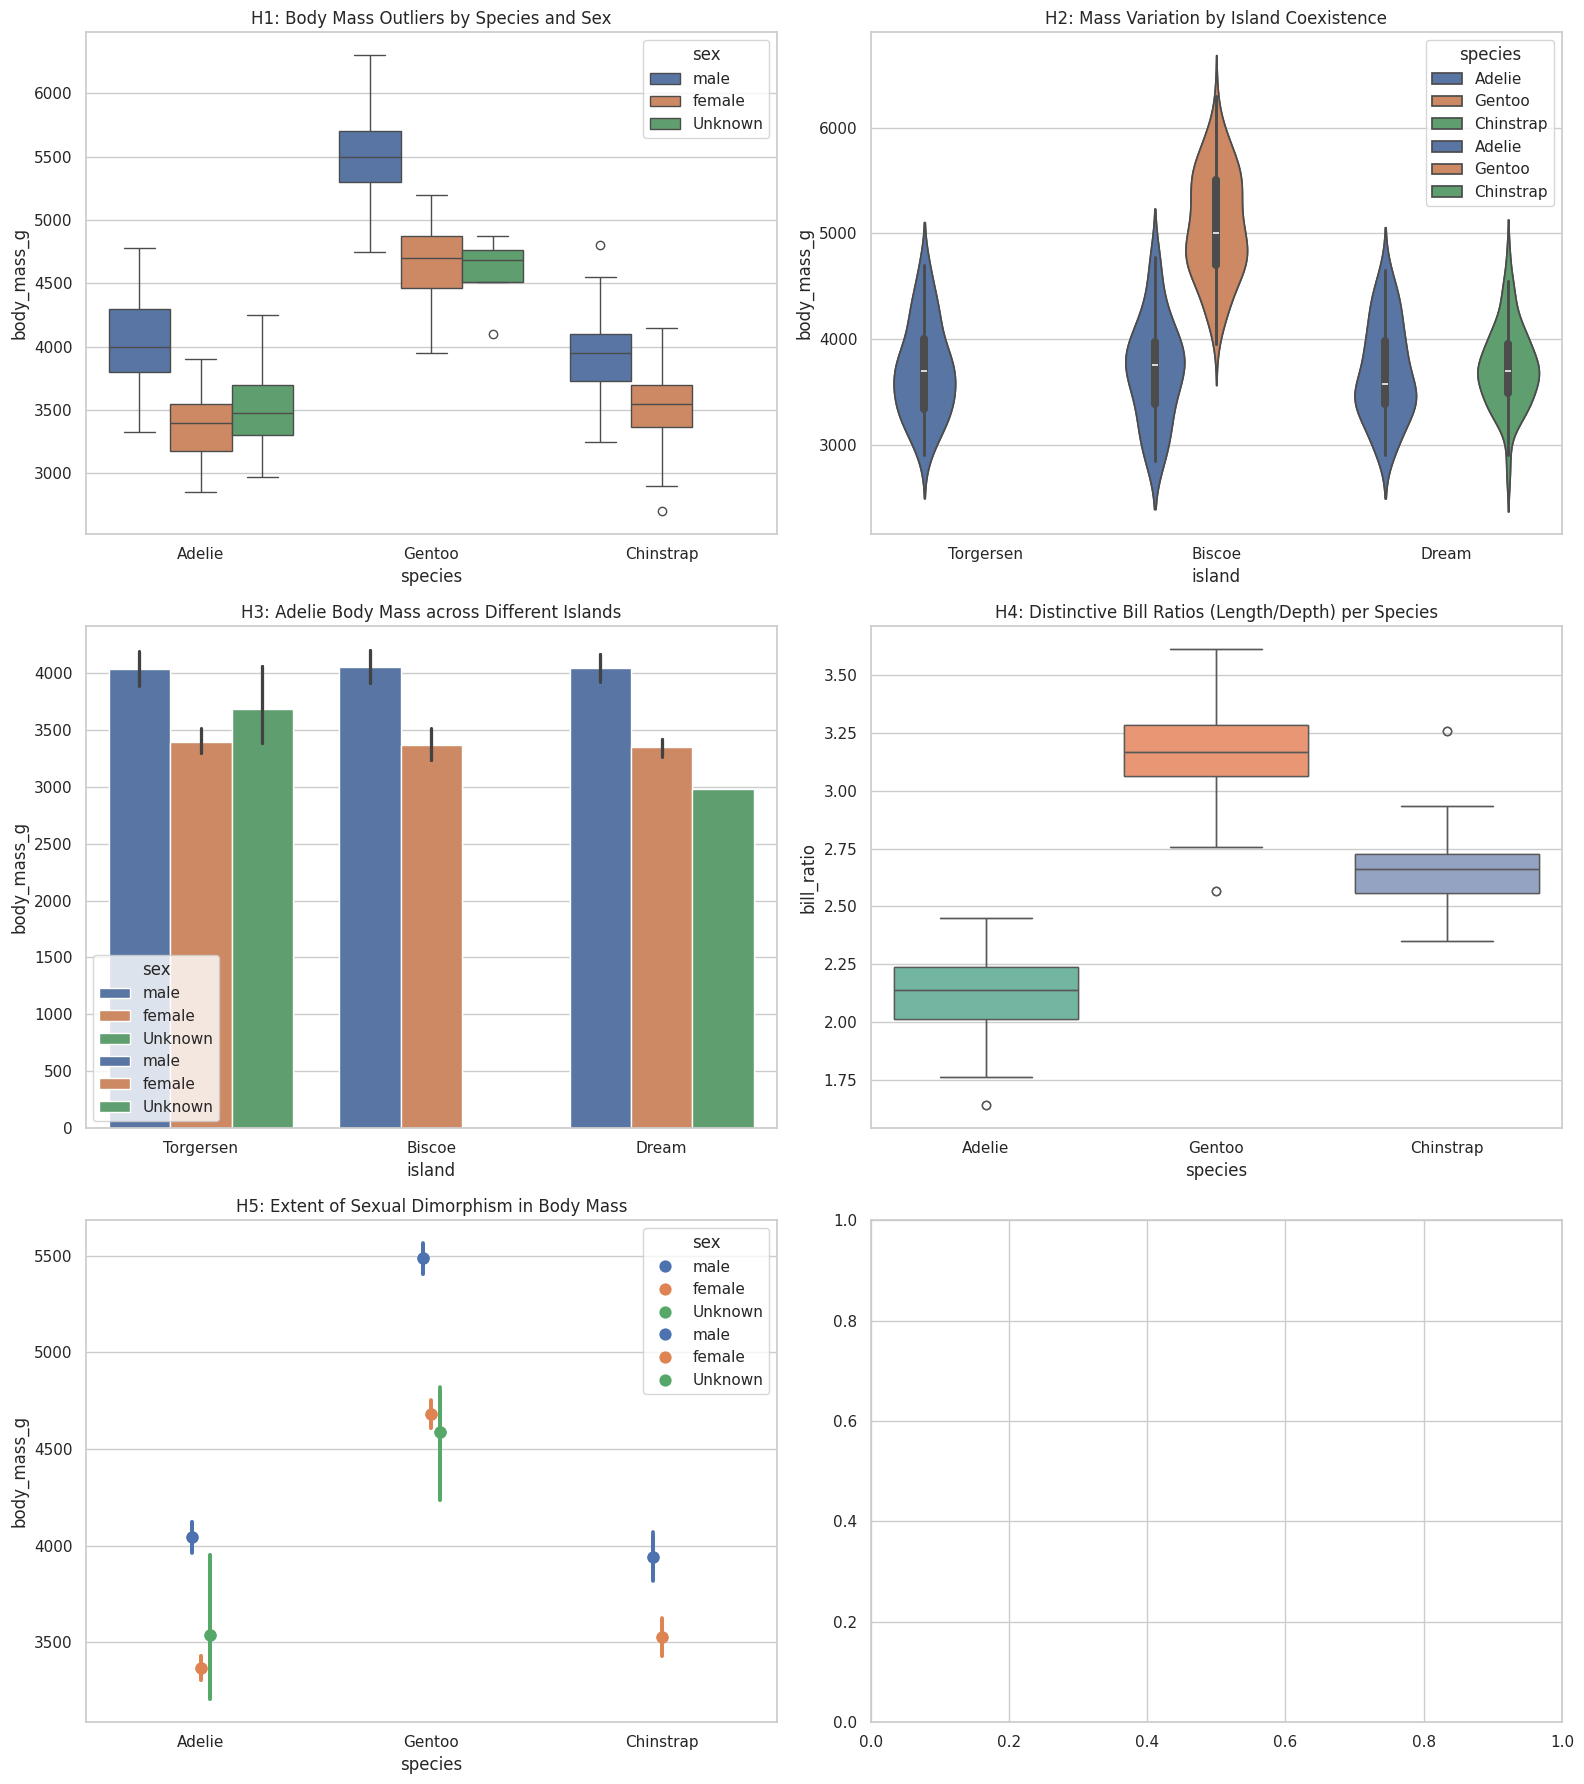

In [28]:
#fig.delaxes(axes[1, 2])

fig.tight_layout()
fig


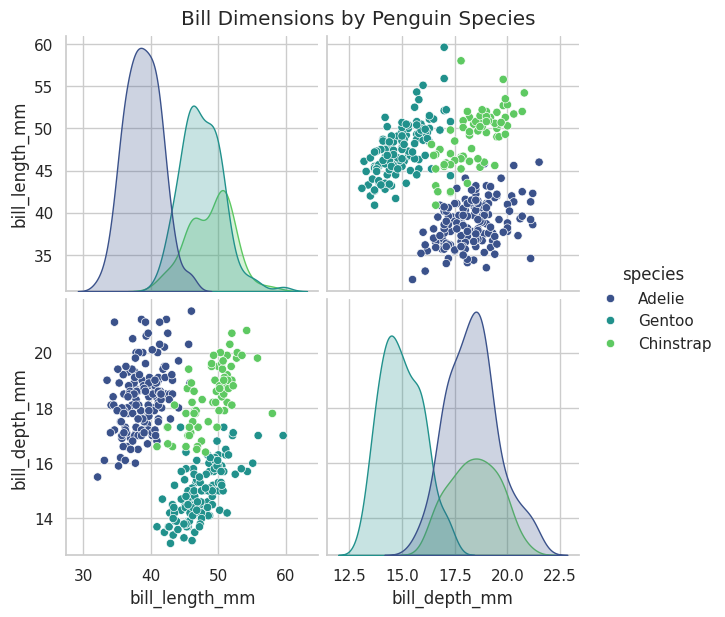

In [31]:
# Used to also show feature correlations
# (like the feature correlation heatmap above) but only for two features

# Hypothesis: Species can be distinguished using the bill length and bill depth

# Observation: As the bill length increases, the bill depth also increases.
# Positive correlation

# This implies that the features can be used to distinguish between species.

sns.pairplot(df_clean,
             vars=['bill_length_mm', 'bill_depth_mm'],
             hue='species',
             palette='viridis',
             height=3)
plt.suptitle('Bill Dimensions by Penguin Species', y=1.02)
plt.show()